## Analytical Solution
#### Using Sisson 1987
##### Brooks-Corey and ROSETTA/van Genuchten Parameters

In [256]:
import numpy as np
import matplotlib.pyplot as plt

##### ROSETTA/vG style soil parameter table

In [257]:
soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    }       
}


In [ ]:
def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)

def kr_van_genuchten_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr

Fitted Brooks-Corey exponent for each soil type 

In [ ]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

In [259]:
for soil_name, soil in soils.items():
    soil["bc_n_fitted"] = fit_n_sisson_to_vg_mualem(
        soil["vg_n"],
        Se_min=0.1,
        Se_max=0.95,
        l=0.5
    )

### Brooks-Corey Conductivity

In [260]:
def K_brooks_corey(theta, theta_c, theta_m, K_m, bc_n):
    Se = (theta - theta_c) / (theta_m - theta_c)
    Se = np.clip(Se, 0, 1)

    K = K_m * Se ** (1 / bc_n)

    return K

##### Conversion of van Genuchten n to Brooks-Corey n REMOVE???

In [261]:
""" def vg_to_bc_n(vg_n):
    
    Placeholder conversion from van Genuchten n to Brooks-Corey/Sisson n.
    This should be checked before final thesis use.

    1 / (vg_n - 1) 
# The vG-to-Brooks-Corey conversion is currently provisional.
# The relationship bc_n = 1/(vg_n - 1) becomes unstable when vg_n is near 2
# and can produce unrealistic analytical profiles.

    return (vg_n - 1) / vg_n
"""

' def vg_to_bc_n(vg_n):\n    \n    Placeholder conversion from van Genuchten n to Brooks-Corey/Sisson n.\n    This should be checked before final thesis use.\n\n    1 / (vg_n - 1) \n# The vG-to-Brooks-Corey conversion is currently provisional.\n# The relationship bc_n = 1/(vg_n - 1) becomes unstable when vg_n is near 2\n# and can produce unrealistic analytical profiles.\n\n    return (vg_n - 1) / vg_n\n'

##### Analytical Solution

In [262]:
def theta_brooks_corey_sisson(z, t, theta_r, theta_s, Ks, bc_n):
    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    s = np.maximum(z / t, 1e-12)

    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / (1 / bc_n - 1)

    Se = (s / A) ** exponent
    theta_raw = theta_r + Se * (theta_s - theta_r)

    theta = np.clip(theta_raw, theta_r, theta_s)

    return theta_raw

In [263]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15
    theta_star = np.empty_like(z)

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

    """# For Brooks-Corey with bc_n < 1:
    # K'(theta_r) = 0 approximately
    # K'(theta_s) = A
    A_min = 0.0
    A_max = A

    drained = s_star <= A_min
    middle = (s_star > A_min) & (s_star < A_max)
    unchanged = s_star >= A_max

    theta_star[drained] = theta_r
    theta_star[middle] = theta_star_mid[middle]
    theta_star[unchanged] = theta_s

    # Safety bounds, but this should no longer be doing the main work
    theta_star = np.clip(theta_star, theta_r, theta_s)

    return theta_star""" 

#### Plot for one soil over a range of times

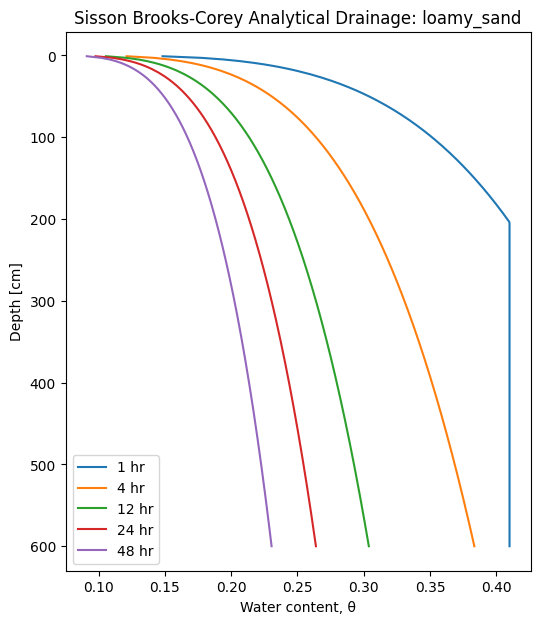

In [264]:
z = np.linspace(1, 600, 300)  # cm, positive downward
times = [1, 4, 12, 24, 48]   # hr

soil_name = "loamy_sand"
soil = soils[soil_name]
bc_n = soil["bc_n_fitted"]
q0 = soil["Ks"]

plt.figure(figsize=(6, 7))

for t in times:

    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=bc_n,
        q0=q0
    )
    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey Analytical Drainage: {soil_name}")
plt.legend()
plt.show()

#### Plot for all soils 

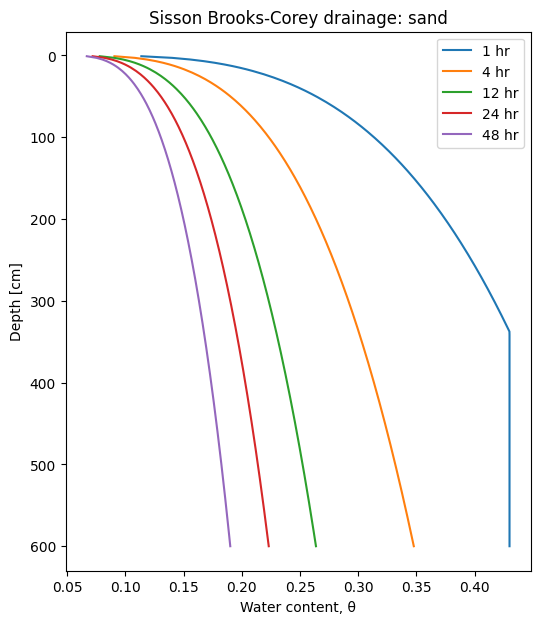

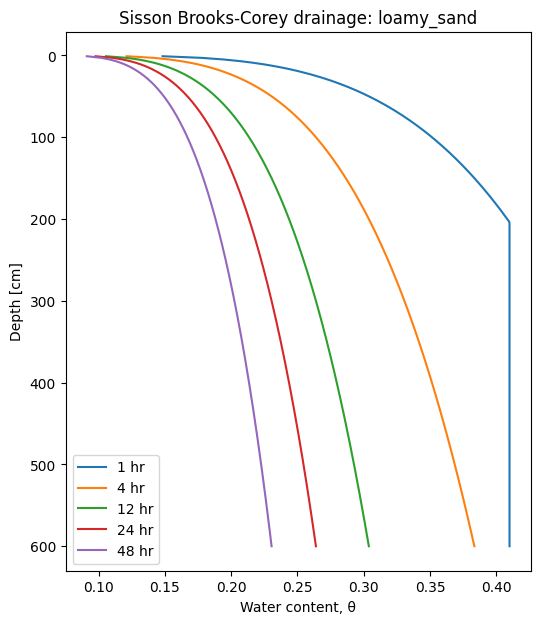

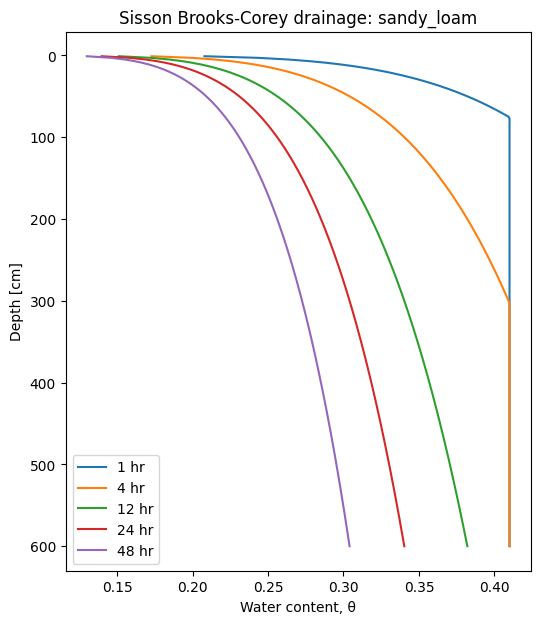

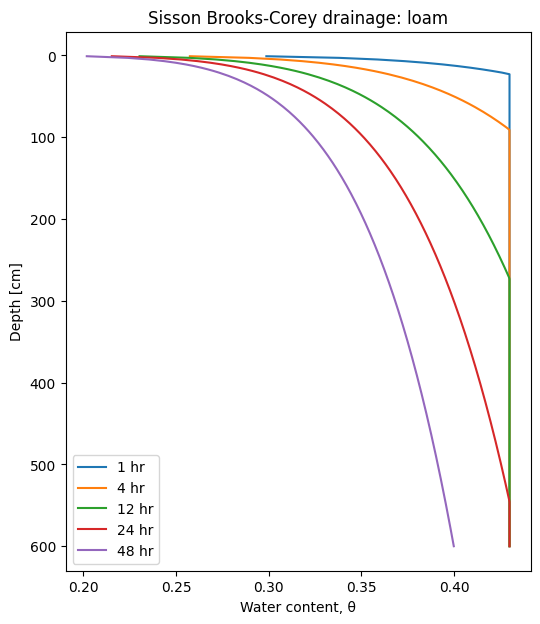

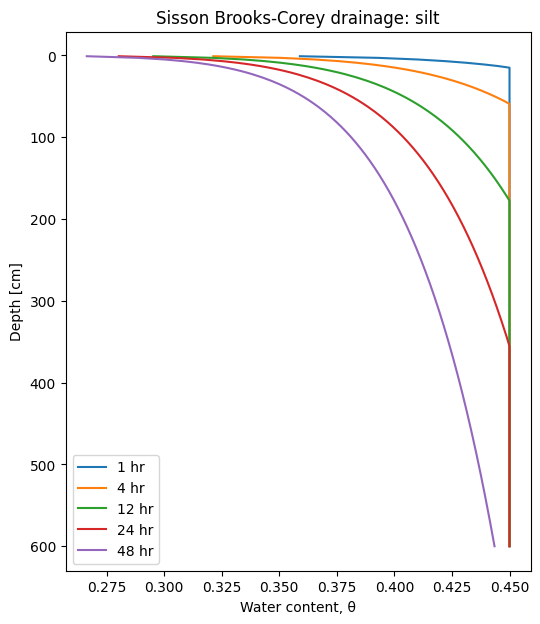

In [265]:
for soil_name, soil in soils.items():

    bc_n = soil["bc_n_fitted"]
    q0 = soil["Ks"]

    plt.figure(figsize=(6, 7))

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=soil["theta_r"],
            theta_s=soil["theta_s"],
            Ks=soil["Ks"],
            bc_n=bc_n,
            q0=q0,
            debug=False
        )

        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"Sisson Brooks-Corey drainage: {soil_name}")
    plt.legend()
    plt.show()